In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Define color variables with hexadecimal color codes
wgc = '#9B765E' # Wave Glider's colour
plt.rcParams['font.size'] = 10

ds = xr.open_dataset('/home/jedholm/share/gliders/waveglider/wg1170/WG_WHIRLS_M2_L1.nc').interpolate_na(dim='time', method='nearest')


In [7]:
ds["WMO_IDENTIFIER"] = (),"WG1170"
ds["WMO_IDENTIFIER"].attrs["long_name"] = "wmo id"

In [ ]:
ds["SENSOR_WEATHER_STATION_YYYY"] = (),""

In [10]:
ds

<xarray.Dataset>
Dimensions:                   (time: 8728, depth: 25)
Coordinates:
  * time                      (time) datetime64[ns] 2026-02-17T07:20:00 ... 2...
    latitude                  (time) float64 ...
    longitude                 (time) float64 ...
  * depth                     (depth) float64 6.0 10.0 14.0 ... 90.0 93.0 97.0
Data variables: (12/34)
    TEMP_AIR_AIRMAR_MEAN      (time) float64 20.6 19.6 20.7 ... 14.8 14.7 14.6
    BARO_PRES_AIRMAR_MEAN     (time) float64 1.014e+03 1.014e+03 ... 990.4 990.4
    WIND_FROM_AIRMAR_MEAN     (time) float64 314.3 326.8 349.3 ... 86.5 88.1
    WIND_FROM_AIRMAR_STDDEV   (time) float64 17.3 51.8 29.3 ... 62.6 49.4 39.9
    GUST_WND_DIR_AIRMAR_MEAN  (time) float64 158.5 316.2 359.3 ... 72.8 88.4
    WIND_SPEED_AIRMAR_MEAN    (time) float64 0.9774 1.132 1.029 ... 2.109 3.292
    ...                        ...
    WAVE_DOMINANT_PERIOD      (time) float64 nan nan nan ... 9.481 9.481 11.13
    WAVE_DOMINANT_DIRECTION   (time) float64 nan nan nan ... 219.8 219.8 231.2
    WATER_CURRENT_EAST_MEAN   (depth, time) float64 nan nan nan ... nan nan nan
    WATER_CURRENT_NORTH_MEAN  (depth, time) float64 nan nan nan ... nan nan nan
    WMO_IDENTIFIER            <U6 'WG1170'
    AIRMAR_200WX_YYYY         <U1 ''
Attributes: (12/36)
    naming_authority:          polargliders.com
    Conventions:               CF-1.10, ACDD-1.3
    standard_name_vocabulary:  CF Standard Name Table v79
    keywords:                  trajectory, uncrewed surface vehicle, Waveglid...
    featureType:               Trajectory
    cdm_data_type:             Trajectory
    ...                        ...
    geospatial_lat_min:        -36.312295
    geospatial_lat_max:        -33.198915
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        15.34019
    geospatial_lon_max:        18.4261716666667
    geospatial_lon_units:      degrees_east

In [15]:
test = xr.open_dataset("/home/jedholm/share/www/data/sg267_WHIRLS_Mission2_2026/p2670021.nc")

In [16]:
test

<xarray.Dataset>
Dimensions:                                    (gc_event: 22, gc_state: 10,
                                                gps_info: 3,
                                                depth_data_point: 277,
                                                legato_data_point: 283,
                                                sg_data_point: 281,
                                                ctd_data_point: 283,
                                                magnetometer_data_point: 281,
                                                trajectory: 1)
Coordinates:
    ctd_time                                   (ctd_data_point) datetime64[ns] ...
    ctd_depth                                  (ctd_data_point) float64 ...
    latitude                                   (ctd_data_point) float64 ...
    longitude                                  (ctd_data_point) float64 ...
  * trajectory                                 (trajectory) int32 21
Dimensions without coordinates: gc_event, gc_state, gps_info, depth_data_point,
                                legato_data_point, sg_data_point,
                                ctd_data_point, magnetometer_data_point
Data variables: (12/542)
    sg_cal_id_str                              |S3 ...
    sg_cal_mission_title                       |S25 ...
    sg_cal_mass                                float64 ...
    sg_cal_use_adcppressure                    int32 ...
    sg_cal_sg_ct_type                          int32 ...
    sg_cal_calibcomm                           |S42 ...
    ...                                         ...
    eng_mag_x                                  (magnetometer_data_point) float64 ...
    eng_mag_y                                  (magnetometer_data_point) float64 ...
    eng_mag_z                                  (magnetometer_data_point) float64 ...
    glider                                     |S15 ...
    magnetometer                               |S12 ...
    legato                                     |S6 ...
Attributes: (12/48)
    time_coverage_start:             2026-02-20T20:02:39Z
    time_coverage_end:               2026-02-20T20:02:44Z
    geospatial_lat_min:              -33.90575468746616
    geospatial_lat_max:              -33.90421666666667
    geospatial_lon_min:              18.267105062888028
    geospatial_lon_max:              18.269067790966396
    ...                              ...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    Conventions:                     CF-1.6
    standard_name_vocabulary:        CF-1.6
    featureType:                     trajectory
    cdm_data_type:                   Trajectory
    nodc_template_version:           NODC_NetCDF_Trajectory_Template_v0.9

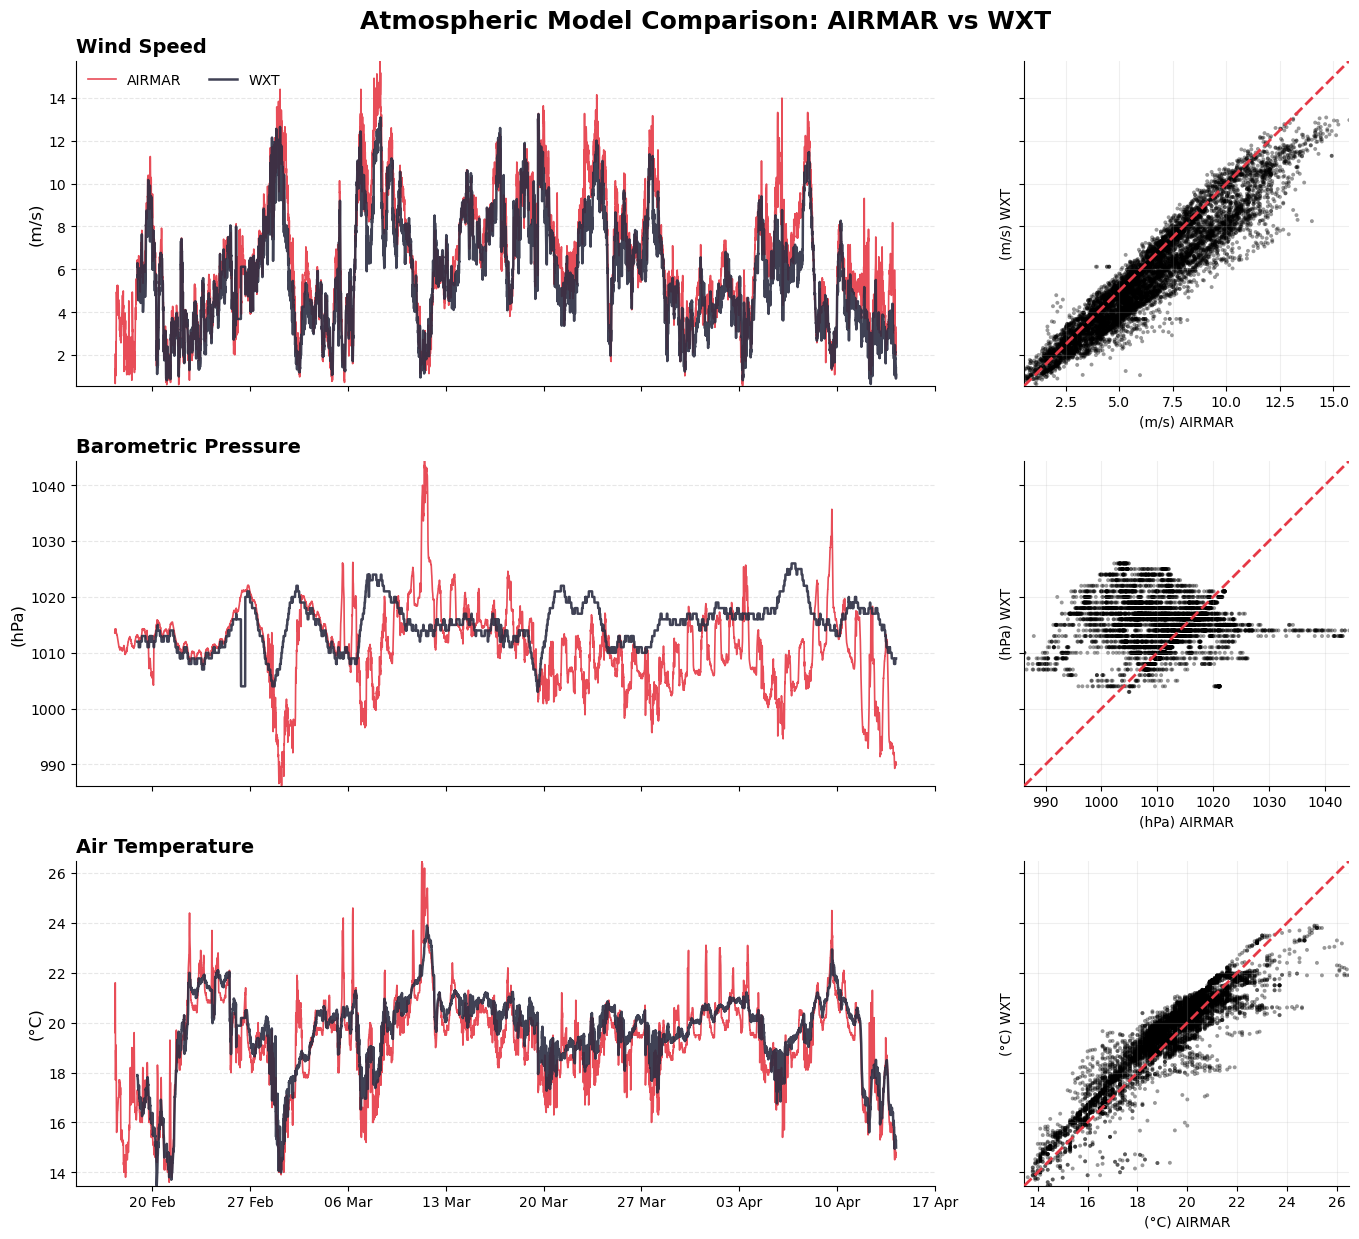

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Define metadata for clean labeling
meta = {
    "WIND_SPEED": {"label": "Wind Speed", "unit": "m/s"},
    "BARO_PRES": {"label": "Barometric Pressure", "unit": "hPa"},
    "TEMP_AIR": {"label": "Air Temperature", "unit": "°C"}
}

# 2. Setup Figure
fig, axs = plt.subplots(3, 2, figsize=(14, 12), 
                        constrained_layout=True, 
                        width_ratios=[2, 1], 
                        sharey="row")

variables = ["WIND_SPEED", "BARO_PRES", "TEMP_AIR"]
models = ["AIRMAR", "WXT"]
colors = ["#e63946", "#2b2d42"]  # Slightly more modern crimson/dark-navy
lws = [1.2, 1.8]

for i, (var, row) in enumerate(zip(variables, axs)):
    ax, bx = row  # Unpack the two axes in the current row
    
    # --- Left Column: Time Series ---
    for model, color, lw in zip(models, colors, lws):
        ds_var = ds[f"{var}_{model}_MEAN"]
        ax.plot(ds_var.time, ds_var.values, label=model, color=color, lw=lw, alpha=0.9)
    
    # Formatting Time Series
    ax.set_title(f"{meta[var]['label']}", loc='left', fontweight='bold', fontsize=14)
    ax.set_ylabel(f"({meta[var]['unit']})", fontsize=12)
    ax.grid(axis="y", alpha=0.3, ls='--')
    ax.spines[["top","right"]].set_visible(False)
    ax.label_outer()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    
    # Legend only on the top plot
    if i == 0:
        ax.legend(frameon=False, loc='upper left', ncol=2)

    # --- Right Column: 1-to-1 Scatter ---
    x_data = ds[f"{var}_AIRMAR_MEAN"].values
    y_data = ds[f"{var}_WXT_MEAN"].values
    
    # Clean scatter
    bx.scatter(x_data, y_data, color="k", s=8, alpha=0.4, edgecolors='none')
    
    # Identify axis limits for equal scaling
    all_data = np.concatenate([x_data[~np.isnan(x_data)], y_data[~np.isnan(y_data)]])
    if all_data.size > 0:
        low, high = all_data.min(), all_data.max()
        bx.set_xlim(low, high)
        bx.set_ylim(low, high)
    
    # Force 1:1 Aspect Ratio
    bx.set_aspect('equal', adjustable='box')
    
    # 1:1 Identity Line
    bx.plot([0, 1], [0, 1], transform=bx.transAxes, color="#e63946", lw=2, ls="--", zorder=3)
    
    bx.set_xlabel(f"({meta[var]['unit']}) AIRMAR", fontsize=10)
    bx.set_ylabel(f"({meta[var]['unit']}) WXT", fontsize=10)
    bx.grid(True, alpha=0.2)
    bx.spines[["top","right"]].set_visible(False)

# Global adjustments
fig.suptitle("Atmospheric Model Comparison: AIRMAR vs WXT", fontsize=18, fontweight='bold', y=1.02)
plt.show()

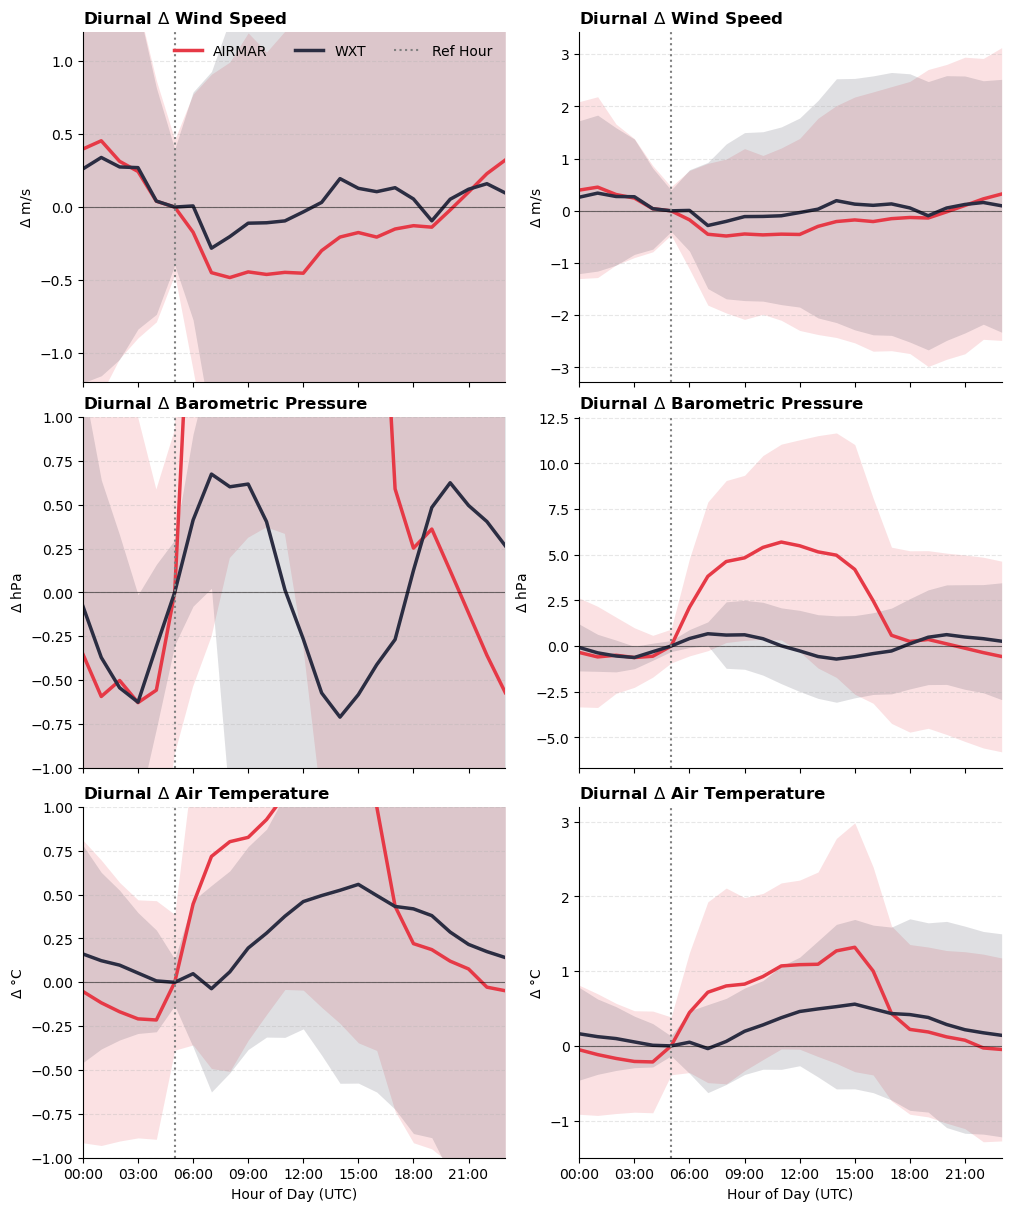

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration
variables = ["WIND_SPEED", "BARO_PRES", "TEMP_AIR"]
ylimits = [[-1.2, 1.2], [-1, 1], [-1, 1]]
models = ["AIRMAR", "WXT"]
colors = ["#e63946", "#2b2d42"]
start_hour = 5

fig, axs = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True, sharex=True)

for i in range(2):
    for var, ax in zip(variables, axs.T[i]):
        if i == 0:
            ax.set_ylim(ylimits[variables.index(var)])
        for model, color in zip(models, colors):
            da = ds[f"{var}_{model}_MEAN"]

            # Step A: Get 06:00 reference for each day
            # We use groupby('time.date') to ensure one value per day
            ref_06 = da.where(da.time.dt.hour == start_hour, drop=True).groupby("time.date").mean()

            # Step B: Calculate Anomaly (Broadcasting subtracts the daily ref from all times)
            anomaly = da.groupby("time.date") - ref_06

            # Step C: Average the anomaly by hour of day
            mu = anomaly.groupby("time.hour").mean()
            sd = anomaly.groupby("time.hour").std()

            # Step D: Plot directly (0-23)
            ax.plot(mu.hour, mu.values, label=model, color=color, lw=2.5)
            ax.fill_between(mu.hour, mu.values - sd.values, mu.values + sd.values, 
                            color=color, alpha=0.15, lw=0)

        # --- Formatting ---
        ax.set_title(f"Diurnal $\Delta$ {meta[var]['label']}", loc='left', fontweight='bold')
        ax.set_ylabel(f"$\Delta$ {meta[var]['unit']}")
        
        # Highlight the Anchor Point
        ax.axhline(0, color='k', lw=0.8, alpha=0.5)
        ax.axvline(start_hour, color='gray', ls=':', lw=1.5, label='Ref Hour')
        
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis='y', ls='--', alpha=0.3)
        
        ax.set_xlim(0, 23)
        ax.set_xticks(range(0, 24, 3))
        ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)])

    axs[0, 0].legend(frameon=False, loc='upper right', ncol=3)
    for ax in axs[-1, :]:
        ax.set_xlabel("Hour of Day (UTC)")
plt.show()

In [2]:
ds1

NameError: name 'ds1' is not defined